# Evaluation Metrics in Classification Projects

**Evaluating the performance of a classification model is an essential step in Machine Learning. Relying only on accuracy can sometimes be misleading, especially when dealing with imbalanced datasets. Therefore, multiple evaluation metrics are used to better understand how well a model performs.**

In this notebook, we explore several important classification evaluation metrics, including:

### Confusion Matrix

**A Confusion Matrix is a table used to evaluate the performance of a classification model by comparing actual values with predicted values.**

It shows how many predictions were correct and how many were incorrect.

**Structure of Confusion Matrix**

| Actual / Predicted | Positive | Negative |
| ------------------ | -------- | -------- |
| **Positive**       | **TP**   | **FN**   |
| **Negative**       | **FP**   | **TN**   |

### TP, TN, FP, FN

| Term   | Full Form      | Meaning                                                      |
| ------ | -------------- | ------------------------------------------------------------ |
| **TP** | True Positive  | Model predicted **Positive** and it is actually **Positive** |
| **TN** | True Negative  | Model predicted **Negative** and it is actually **Negative** |
| **FP** | False Positive | Model predicted **Positive** but it is actually **Negative** |
| **FN** | False Negative | Model predicted **Negative** but it is actually **Positive** |

**Example (Disease Detection)**

Suppose a model predicts whether a patient has a disease.

1. True Positive (TP)
    - Model says Disease, and patient actually has disease.

Correct prediction

2. True Negative (TN)
    - Model says No Disease, and patient actually has no disease.

Correct prediction

3. False Positive (FP)
    - Model says Disease, but patient does NOT have disease.

Wrong prediction

Also called Type I Error.

4. False Negative (FN)
    - Model says No Disease, but patient actually has disease.

Wrong prediction

Also called Type II Error.

| Actual     | Predicted  | Result |
| ---------- | ---------- | ------ |
| Disease    | Disease    | TP     |
| No Disease | No Disease | TN     |
| No Disease | Disease    | FP     |
| Disease    | No Disease | FN     |

**Suppose we are predicting whether an email is spam or not.**

| Actual / Predicted | Spam | Not Spam |
| ------------------ | ---- | -------- |
| **Spam**           | 40   | 10       |
| **Not Spam**       | 5    | 45       |

So:

- TP = 40
- FN = 10
- FP = 5
- TN = 45

### Why Confusion Matrix is Important?

**From this table we can calculate many metrics:**

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. TPR
6. FPR
7. Sensitivity
8. Specificity

So confusion matrix is the base for all classification metrics.

In [2]:
from sklearn.metrics import confusion_matrix

y_true = [1,0,1,1,0,1]
y_pred = [1,0,0,1,0,1]

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2 0]
 [1 3]]


### Accuracy

**Accuracy tells us how many predictions the model got correct out of all predictions.**

**Accuracy = Correct Predictions / Total Predictions**

**Formula:**    

Accuracy = $\frac{TP + TN}{TP + TN + FP + FN}$

**Where:**

- TP → True Positive
- TN → True Negative
- FP → False Positive
- FN → False Negative

**Example:**

Suppose we have 100 predictions:

| Type | Count |
|------|-------|
| TP   | 40    |
| TN   | 45    |
| FP   | 5     |
| FN   | 10    |

**Total = 100**

$
Accuracy = \frac{40 + 45}{100}
$

$
Accuracy = \frac{85}{100} = 0.85
$

Accuracy = 85%

Meaning the model predicted 85% of the cases correctly.

**Accuracy is not good for imbalanced datasets.**

Example:

If 95% data = negative, a model predicting all negative will still give 95% accuracy, but the model is useless.

In [1]:
from sklearn.metrics import accuracy_score

y_true = [1,0,1,1,0]
y_pred = [1,0,1,0,0]

accuracy = accuracy_score(y_true, y_pred)

print(accuracy)

0.8


### Precision

**Precision is the ratio of correctly predicted positive observations to the total predicted positives.**

It measures how accurate the positive predictions are.

**Formula:**

Precision = $\frac{TP}{TP + FP}$

**Example**

Suppose a model predicts Spam Emails

| Prediction | Actual   | Result |
| ---------- | -------- | ------ |
| Spam       | Spam     | TP     |
| Spam       | Spam     | TP     |
| Spam       | Not Spam | FP     |
| Spam       | Spam     | TP     |

So:

- TP = 3
- FP = 1

Precision = $\frac{3}{3 + 1}=\frac{3}{4} = 0.75$

**Precision = 75%**

Meaning 75% of the emails predicted as spam were actually spam.

### When Precision is Important

**Precision is important when False Positives are costly.**

**Examples:**

- Spam detection
- Fraud detection
- Medical diagnosis

In [3]:
from sklearn.metrics import precision_score

y_true = [1,0,1,1,0]
y_pred = [1,1,1,0,0]

precision = precision_score(y_true, y_pred)

print(precision)

0.6666666666666666


### Recall

**Out of all the actual positive cases, how many did the model correctly identify.**

It measures how well the model finds all positive cases.

Recall = $\frac{TP}{TP + FN}$

**Example**

Suppose we are predicting whether a patient has a disease.

| Prediction | Actual  | Result |
| ---------- | ------- | ------ |
| Disease    | Disease | TP     |
| Disease    | Disease | TP     |
| No Disease | Disease | FN     |
| Disease    | Disease | TP     |

So:

- TP = 3
- FN = 1

$
Recall = \frac{3}{3 + 1} = \frac{3}{4} = 0.75
$

**Recall = 75%**

Meaning the model correctly detected 75% of the patients who actually had the disease.

### When Recall is Important

**Recall is important when missing a positive case is dangerous.**

**Examples:**

- Disease detection
- Fraud detection
- Cancer detection

Because False Negatives are very risky.

In [4]:
from sklearn.metrics import recall_score

y_true = [1,0,1,1,0]
y_pred = [1,0,0,1,0]

recall = recall_score(y_true, y_pred)

print(recall)

0.6666666666666666


### F1 Score

**F1 Score is a metric that combines Precision and Recall into a single value.**

**It is the harmonic mean of Precision and Recall.**

**It is used when we want a balance between Precision and Recall.**

F1 Score = $\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$

**Example**

Suppose:

- Precision = 0.80
- Recall = 0.60

$$
F1 = \frac{2 \cdot 0.80 \cdot 0.60}{0.80 + 0.60}
$$
$$
F1 = \frac{2 \cdot 0.48}{1.40}
$$

$$
F1 = \frac{0.96}{1.40} = 0.68
$$

F1 Score = 0.68

### Why F1 Score is Important

**Accuracy can be misleading when data is imbalanced.**

**Example:**

- 95% = Negative class
- 5% = Positive class

A model predicting all negatives gives 95% accuracy, but it is useless.

So we use F1 Score, because it considers:

- Precision
- Recall

In [5]:
from sklearn.metrics import f1_score

y_true = [1,0,1,1,0]
y_pred = [1,0,0,1,0]

f1 = f1_score(y_true, y_pred)

print(f1)

0.8


### TPR (True Positive Rate)

**TPR measures how many actual positive cases the model correctly identifies.**

It tells us how good the model is at detecting positive cases.

TPR is the same as Recall and Sensitivity.

So:

**TPR=Recall=Sensitivity**

### Where TPR is Used

**TPR is mainly used in:**

- ROC Curve
- Binary classification evaluation

### FPR (False Positive Rate)

**False Positive Rate (FPR) measures:**

Out of all actual negative cases, how many were incorrectly predicted as positive.

It shows how often the model makes a false alarm.

**Formula**

FPR = $\frac{FP}{FP + TN}$

### Where FPR is Used

**FPR is mainly used in:**

- ROC Curve
- Binary classification evaluation

**In ROC Curve:**

- X-axis → FPR
- Y-axis → TPR

### Specificity

**Specificity measures:**

Out of all actual negative cases, how many were correctly predicted as negative.

It shows how well the model identifies the negative class.

**Formula**

Specificity = $\frac{TN}{TN + FP}$

#### Relationship with FPR

**Specificity = 1 - FPR**

### ROC Curve (Receiver Operating Characteristic Curve)

**The ROC Curve is a graph used to evaluate the performance of a binary classification model at different threshold values.**

It shows the relationship between:

- TPR (True Positive Rate / Recall) → Y-axis
- FPR (False Positive Rate) → X-axis

**ROC Curve Axes**

| Axis       | Metric               |
| ---------- | -------------------- |
| **X-axis** | FPR = FP / (FP + TN) |
| **Y-axis** | TPR = TP / (TP + FN) |

- So the curve shows how TPR changes when FPR changes.

#### What ROC Curve Tells

- It helps us understand how well the model separates positive and negative classes.
- Better models push the curve towards the top-left corner.

| Model         | ROC Shape              |
| ------------- | ---------------------- |
| Perfect model | Curve near top-left    |
| Good model    | Curve above diagonal   |
| Random model  | Straight diagonal line |

**Example Use Cases**

ROC curve is commonly used in:

- Medical diagnosis
- Fraud detection
- Spam detection
- Credit risk prediction

### AUC Score (Area Under the ROC Curve)

**It measures how well a classification model can distinguish between positive and negative classes.**

AUC tells how good the model is at separating the two classes.

**Range of AUC**

| AUC Value      | Meaning           |
| -------------- | ----------------- |
| **1.0**        | Perfect model     |
| **0.9 – 0.99** | Excellent         |
| **0.8 – 0.9**  | Good              |
| **0.7 – 0.8**  | Fair              |
| **0.5**        | Random model      |
| **< 0.5**      | Worse than random |

**Intuition**

Suppose we randomly choose:

- one positive sample
- one negative sample

If the model gives higher probability to the positive sample, that means the model is doing a good job.

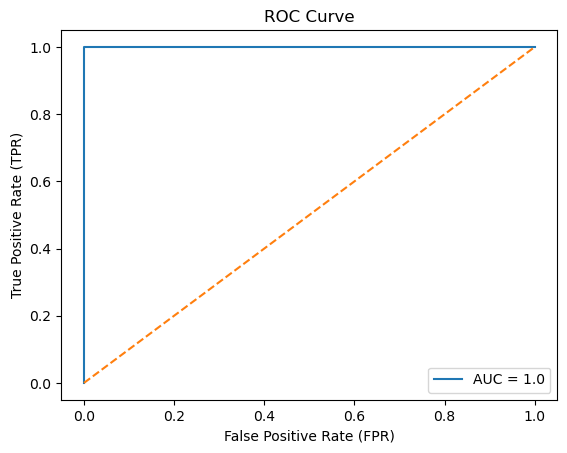

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Actual labels (0 = Negative, 1 = Positive)
y_true = [0, 0, 1, 1, 0, 1, 0, 1, 1, 0]

# Predicted probabilities
y_scores = [0.05, 0.2, 0.9, 0.8, 0.3, 0.7, 0.4, 0.85, 0.65, 0.1]

# Calculate FPR, TPR
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate AUC score
auc = roc_auc_score(y_true, y_scores)

# Plot ROC Curve
plt.plot(fpr, tpr, label="AUC = " + str(round(auc,2)))
plt.plot([0,1], [0,1], linestyle='--')   # Random model line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()